In [224]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [225]:
df = pd.read_csv('insurance.csv')
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [226]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [227]:
df.duplicated().sum()

np.int64(1)

In [228]:
df = df.drop_duplicates()

In [229]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   object 
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   object 
 5   region    1337 non-null   object 
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 83.6+ KB


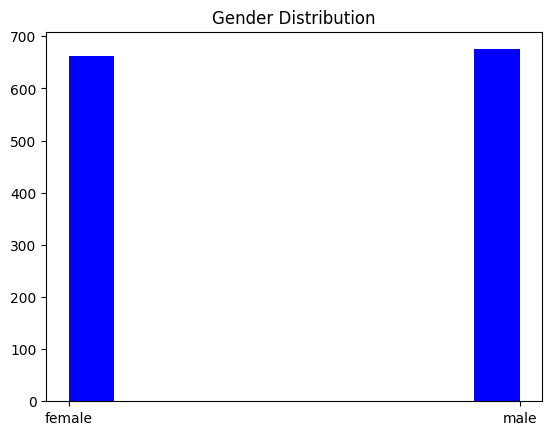

sex
male      675
female    662
Name: count, dtype: int64

In [230]:
plt.hist(df.sex, color = 'blue', label = 'gender')
plt.title('Gender Distribution')
plt.show()
#Almost Equal
df.sex.value_counts()

In [231]:
df.groupby('sex')['charges'].sum() #Male spents more as campare to females

sex
female    8.321061e+06
male      9.433124e+06
Name: charges, dtype: float64

In [232]:
df.pivot_table(index='sex', columns='smoker', aggfunc='size')

smoker,no,yes
sex,,
female,547,115
male,516,159


In [233]:
df['sex'] = df['sex'].map({'male':0, 'female':1})
df['smoker'] = df['smoker'].map({'yes':1, 'no':0}) 
df

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,northwest,10600.54830
1334,18,1,31.920,0,0,northeast,2205.98080
1335,18,1,36.850,0,0,southeast,1629.83350
1336,21,1,25.800,0,0,southwest,2007.94500


<Axes: >

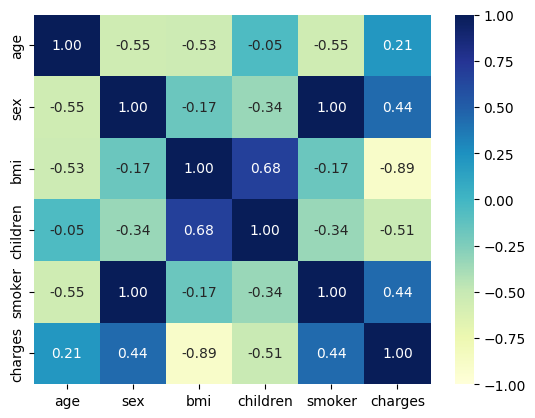

In [234]:
corr = (df[['age','sex','bmi','children', 'smoker', 'charges']].head()).corr()
sns.heatmap(corr, vmin = -1, vmax = 1, annot = True, cmap = 'YlGnBu', fmt = '.2f')

# No any Strong corelation found in any column (No collinearity issue)

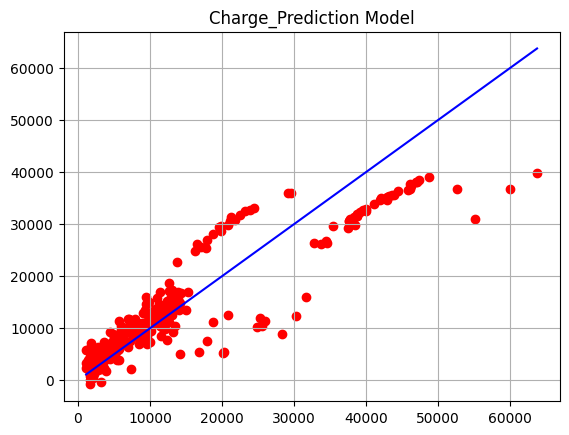

R2 Score = 0.8046218811772661
Mean Absolute Error = 4198.111800474601
Mean Squared Error = 35901914.11461982


In [238]:
X  = df[['age','sex','bmi','children', 'smoker']]
y = df['charges']

x_train, x_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)
model = LinearRegression()
model.fit(x_train, y_train)

y_pred  = model.predict(x_test)

plt.scatter(y_test, y_pred, color = 'red', label = 'charges_predicted')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color = 'blue')
plt.title('Charge_Prediction Model')
plt.grid()
plt.show()


print(f'R2 Score = {r2_score(y_test, y_pred)}')
print(f'Mean Absolute Error = {mean_absolute_error(y_test, y_pred)}')
print(f'Mean Squared Error = {mean_squared_error(y_test, y_pred)}')